In [3]:
import pandas as pd
import matplotlib.pyplot as plt

ts = pd.read_csv("data/monthly_revenue.csv", parse_dates=['month'])
ts = ts.set_index('month')
print(ts.head())
print(ts.shape)

             revenue
month               
2021-01-01  47298.11
2021-02-01  45792.60
2021-03-01  51996.94
2021-04-01  57891.13
2021-05-01  58785.68
(48, 1)


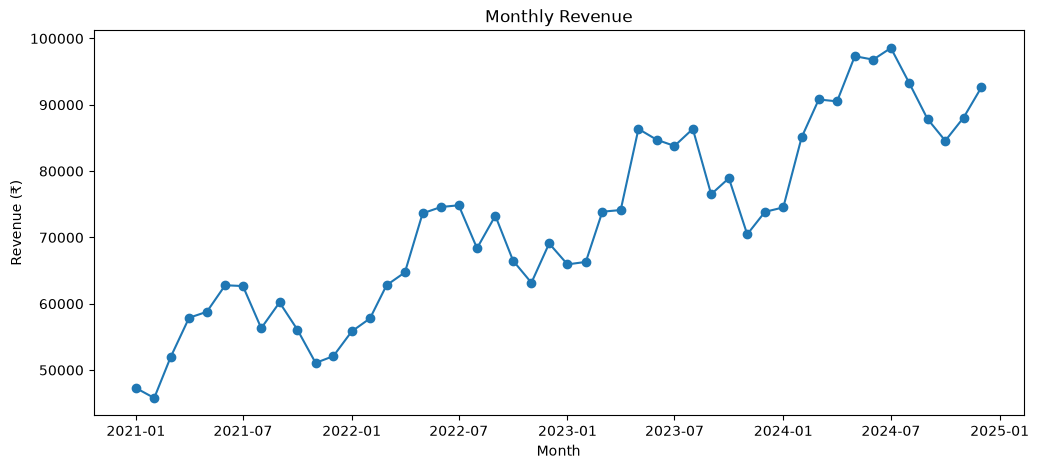

In [4]:
plt.figure(figsize=(12,5))
plt.plot(ts.index, ts['revenue'], marker='o')
plt.title('Monthly Revenue')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.show()

In [5]:
# Hold out the last 6 months as validation
train = ts.iloc[:-6]
test = ts.iloc[-6:]

print("Train period:", train.index.min(), "to", train.index.max(), "-", len(train), "months")
print("Test period:", test.index.min(), "to", test.index.max(), "-", len(test), "months")

Train period: 2021-01-01 00:00:00 to 2024-06-01 00:00:00 - 42 months
Test period: 2024-07-01 00:00:00 to 2024-12-01 00:00:00 - 6 months


In [6]:
# Naive baseline: predict every future month = the last known value from training
last_value = train['revenue'].iloc[-1]
naive_forecast = [last_value] * len(test)

print("Last training value:", round(last_value, 2))
print("Naive forecast (repeated):", naive_forecast)

Last training value: 96805.35
Naive forecast (repeated): [np.float64(96805.35), np.float64(96805.35), np.float64(96805.35), np.float64(96805.35), np.float64(96805.35), np.float64(96805.35)]


In [7]:
import numpy as np

naive_errors = test['revenue'].values - naive_forecast
naive_mae = np.mean(np.abs(naive_errors))
print("Naive baseline MAE (Mean Absolute Error):", round(naive_mae, 2))

Naive baseline MAE (Mean Absolute Error): 6561.52


In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train['revenue'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

forecast = model.forecast(6)
print(forecast)

C:\Users\HP\placemux-phase1\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2024-07-01    97001.321185
2024-08-01    93844.281818
2024-09-01    93225.173659
2024-10-01    90641.793866
2024-11-01    84906.092216
2024-12-01    88266.122288
Freq: MS, dtype: float64


In [9]:
model_errors = test['revenue'].values - forecast.values
model_mae = np.mean(np.abs(model_errors))
print("Model MAE:", round(model_mae, 2))
print("Naive baseline MAE:", round(naive_mae, 2))
print("Improvement:", round((naive_mae - model_mae) / naive_mae * 100, 1), "% better than baseline")

Model MAE: 3511.28
Naive baseline MAE: 6561.52
Improvement: 46.5 % better than baseline


In [10]:

final_model = ExponentialSmoothing(
    ts['revenue'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()


future_forecast = final_model.forecast(6)
print(future_forecast)

C:\Users\HP\placemux-phase1\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


2025-01-01     88709.798836
2025-02-01     90525.590070
2025-03-01     96873.104351
2025-04-01    100139.887432
2025-05-01    105458.310785
2025-06-01    107458.863835
Freq: MS, dtype: float64


In [11]:

margin = model_mae * 1.96  

lower_bound = future_forecast - margin
upper_bound = future_forecast + margin

forecast_table = pd.DataFrame({
    'forecast': future_forecast.round(2),
    'lower_95': lower_bound.round(2),
    'upper_95': upper_bound.round(2)
})
print(forecast_table)

             forecast   lower_95   upper_95
2025-01-01   88709.80   81827.69   95591.91
2025-02-01   90525.59   83643.48   97407.70
2025-03-01   96873.10   89990.99  103755.21
2025-04-01  100139.89   93257.78  107022.00
2025-05-01  105458.31   98576.20  112340.42
2025-06-01  107458.86  100576.75  114340.97


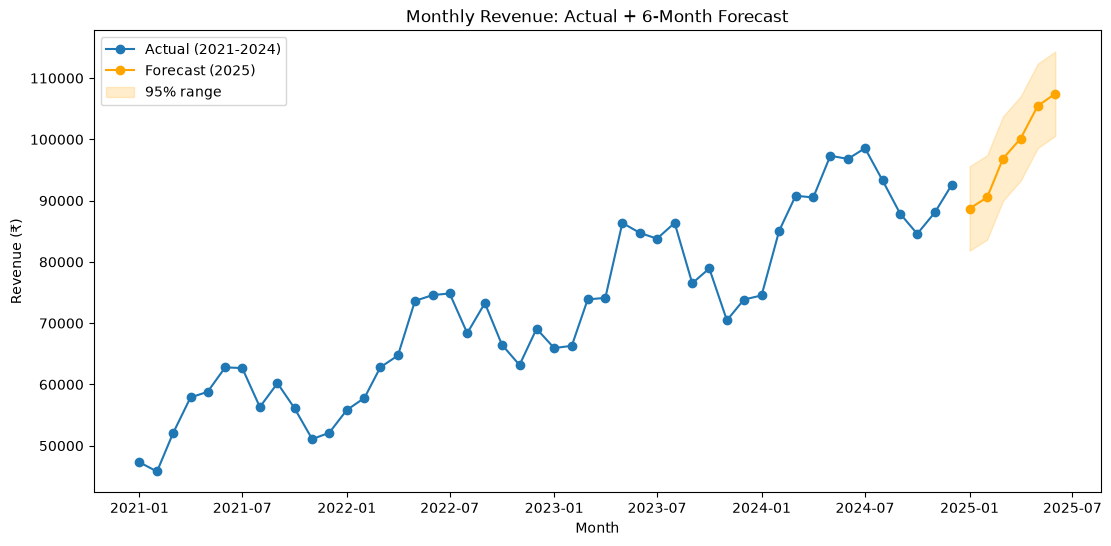

In [12]:
plt.figure(figsize=(13,6))
plt.plot(ts.index, ts['revenue'], label='Actual (2021-2024)', marker='o')
plt.plot(future_forecast.index, future_forecast.values, label='Forecast (2025)', marker='o', color='orange')
plt.fill_between(future_forecast.index, lower_bound, upper_bound, color='orange', alpha=0.2, label='95% range')
plt.title('Monthly Revenue: Actual + 6-Month Forecast')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.legend()
plt.show()

## Forecast Assumptions & Limitations

**Assumptions made:**
- The yearly seasonal pattern observed in 2021-2024 (lower mid-year, higher toward year-end) will continue unchanged into 2025.
- The underlying growth trend will continue at a similar pace — no major shocks (e.g. a new competitor, economic downturn, supply issue) are accounted for.
- This data is synthetic practice data, not the real PlaceMux business — the modeling approach is what's being demonstrated, not the specific numbers.

**Where this forecast is least reliable:**
- The forecast gets less reliable the further out it goes — month 6 (June 2025) has more uncertainty baked in than month 1 (Jan 2025), even though the displayed margin is currently constant; a more advanced approach would widen the band further into the future.
- Only 4 years of history (48 months) were available — with just 4 yearly cycles to learn the seasonal pattern from, the model has limited data to confirm the seasonality is a stable, repeating pattern rather than partly coincidental.
- The model assumes the future will behave like the past — any real-world disruption (a sudden change in customer demand, pricing changes, etc.) would not be captured by this approach.